<a href="https://colab.research.google.com/github/msamir-dls/PEFT_LoRA_QLoRA/blob/main/LoRA_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: INSTALL DEPENDENCIES
# ─────────────────────────────────────────────────────────────────────────────

In [1]:
# Run these in Colab before executing this script:
#
!pip install -q -U trl transformers accelerate peft
!pip install -q datasets bitsandbytes wandb matplotlib
!pip install -q ninja packaging
# !pip install -q flash-attn --no-build-isolation
#
# Then authenticate with HuggingFace (required for Llama-3 gated weights):
from huggingface_hub import notebook_login; notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 158.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [1]:
import os
import gc
import json
import time
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

 ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: CENTRALIZED CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
@dataclass
class ExperimentConfig:
    """
    Master configuration for the multi-rank LoRA sweep.

    Mathematical note on rank/alpha relationship:
        LoRA forward: h = W₀x + (α/r) · BAx
        Setting α = 2r keeps the effective scaling (α/r = 2) constant
        across all ranks. This isolates the effect of rank on capacity
        without confounding it with signal magnitude.
    """
    # ── Model & Data ──────────────────────────────────────────────────────────
    model_name: str           = "meta-llama/Meta-Llama-3-8B-Instruct"
    dataset_name: str         = "timdettmers/openassistant-guanaco"
    output_root: str          = "./lora_rank_experiments"

    # ── LoRA Sweep ────────────────────────────────────────────────────────────
    # α = 2r is enforced automatically in the sweep loop
    lora_ranks: List[int]     = field(default_factory=lambda: [4, 8, 16, 32, 64])
    lora_dropout: float       = 0.05
    target_modules: List[str] = field(default_factory=lambda: [
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ])

    # ── Training ──────────────────────────────────────────────────────────────
    num_epochs: int           = 1
    batch_size: int           = 2
    grad_accum_steps: int     = 4
    # Effective batch = 2 × 4 = 8 samples per weight update
    learning_rate: float      = 1e-4
    max_seq_length: int       = 1024
    weight_decay: float       = 0.001
    max_grad_norm: float      = 0.3
    warmup_ratio: float       = 0.05
    lr_scheduler_type: str    = "cosine"

    # ── Quantization (QLoRA) ──────────────────────────────────────────────────
    use_4bit: bool            = True
    bnb_4bit_compute_dtype: str = "bfloat16"
    use_nested_quant: bool    = True   # double quantization saves ~0.4 bits/param

    # ── Hardware ──────────────────────────────────────────────────────────────
    bf16: bool                = True   # A100/H100 only; set False + fp16=True for T4
    fp16: bool                = False

    # ── Perplexity Evaluation ─────────────────────────────────────────────────
    # A diverse suite of prompts to measure generalisation
    eval_prompts: List[str]   = field(default_factory=lambda: [
        "Explain the concept of recursion in programming.",
        "What are the main causes of climate change?",
        "How does the human immune system fight infections?",
        "What is the difference between supervised and unsupervised learning?",
        "Describe the events that led to World War I.",
        "Explain how a neural network learns from data.",
        "What are the pros and cons of renewable energy sources?",
        "How do vaccines work to prevent disease?",
    ])

config = ExperimentConfig()

In [3]:
# Detect GPU capabilities
def detect_hardware():
    if not torch.cuda.is_available():
        raise RuntimeError("No CUDA GPU detected. This script requires a GPU.")
    cap = torch.cuda.get_device_capability()
    name = torch.cuda.get_device_name(0)
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    supports_bf16 = cap[0] >= 8
    supports_flash2 = cap[0] >= 8
    print(f"{'='*60}")
    print(f"  GPU : {name}")
    print(f"  VRAM: {total_gb:.1f} GB")
    print(f"  BF16: {'✓' if supports_bf16 else '✗ (use fp16)'}")
    print(f"  FlashAttention2: {'✓' if supports_flash2 else '✗ (will skip)'}")
    print(f"{'='*60}")
    return supports_bf16, supports_flash2

SUPPORTS_BF16, SUPPORTS_FLASH2 = detect_hardware()
if not SUPPORTS_BF16:
    config.bf16 = False
    config.fp16 = True
    config.bnb_4bit_compute_dtype = "float16"
    print("Auto-switched to fp16 mode for legacy GPU.")

os.makedirs(config.output_root, exist_ok=True)

  GPU : NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB
  BF16: ✓
  FlashAttention2: ✓


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: QUANTIZATION & BASE MODEL LOADER
# ─────────────────────────────────────────────────────────────────────────────


In [4]:
def build_bnb_config(cfg: ExperimentConfig) -> BitsAndBytesConfig:
    """
    NF4 Quantization Config.

    NF4 is information-theoretically optimal for normally distributed weights.
    Quantization levels qᵢ = Φ⁻¹(i / (2^k + 1)) where Φ⁻¹ is the inverse
    normal CDF and k=4, giving 16 levels concentrated near zero where most
    weight mass lives.
    """
    compute_dtype = getattr(torch, cfg.bnb_4bit_compute_dtype)
    return BitsAndBytesConfig(
        load_in_4bit=cfg.use_4bit,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=cfg.use_nested_quant,
    )

In [5]:
def load_base_model_and_tokenizer(cfg: ExperimentConfig):
    """
    Load the base model in 4-bit (QLoRA) with optional Flash Attention 2.
    Returns (model, tokenizer) ready for training.
    """
    compute_dtype = getattr(torch, cfg.bnb_4bit_compute_dtype)
    bnb_config = build_bnb_config(cfg)

    kwargs = dict(
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=compute_dtype,
        attn_implementation="sdpa"
    )
    # if SUPPORTS_FLASH2:
    #     kwargs["attn_implementation"] = "flash_attention_2"

    print(f"\n  Loading base model: {cfg.model_name} ...")
    model = AutoModelForCausalLM.from_pretrained(cfg.model_name, **kwargs)
    model = prepare_model_for_kbit_training(model)
    model.gradient_checkpointing_enable()
    model.config.use_cache = False       # Must be False during training
    model.config.pretraining_tp = 1

    # Cast all LayerNorm layers to float32 for numerical stability
    for name, module in model.named_modules():
        if "norm" in name.lower():
            module.to(torch.float32)

    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    # "right" padding for training (SFT packs sequences left-to-right)
    tokenizer.padding_side = "right"

    print("  Base model and tokenizer loaded.")
    return model, tokenizer

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: PERPLEXITY EVALUATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────

In [6]:
@torch.inference_mode()
def compute_perplexity(
    model,
    tokenizer,
    prompts: List[str],
    max_length: int = 512,
    device: str = "cuda"
) -> Dict[str, float]:
    """
    Compute per-prompt and mean perplexity for a model.

    Perplexity = exp(ℒ) where ℒ = -(1/T) Σₜ log P(uₜ | u<t ; θ)

    A lower perplexity means the model assigns higher probability to
    the ground-truth next tokens — i.e., it "understands" the text better.

    Args:
        model: A loaded HuggingFace causal LM (base or PEFT-merged)
        tokenizer: Corresponding tokenizer
        prompts: List of evaluation strings
        max_length: Truncation length

    Returns:
        Dict with per-prompt PPL and overall mean/std
    """
    # ── Critical fix: re-enable cache for inference ──────────────────────────
    was_training = model.training
    model.eval()
    original_cache_setting = model.config.use_cache
    model.config.use_cache = True

    results = {}
    per_prompt_ppl = []

    for i, prompt in enumerate(prompts):
        # Apply Llama-3 Instruct chat template
        formatted = apply_llama3_chat_template(tokenizer, prompt)
        inputs = tokenizer(
            formatted,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        ).to(device)

        input_ids = inputs["input_ids"]
        # labels = input_ids so the model computes cross-entropy on all tokens
        with torch.no_grad():
            outputs = model(**inputs, labels=input_ids)
            loss = outputs.loss.item()

        ppl = math.exp(loss)
        results[f"prompt_{i}"] = {"text": prompt[:60] + "...", "ppl": round(ppl, 4)}
        per_prompt_ppl.append(ppl)
        print(f"    Prompt {i+1}/{len(prompts)} | loss={loss:.4f} | PPL={ppl:.2f}")

    results["mean_ppl"] = round(float(np.mean(per_prompt_ppl)), 4)
    results["std_ppl"]  = round(float(np.std(per_prompt_ppl)), 4)
    results["min_ppl"]  = round(float(np.min(per_prompt_ppl)), 4)
    results["max_ppl"]  = round(float(np.max(per_prompt_ppl)), 4)

    # Restore state
    model.config.use_cache = original_cache_setting
    if was_training:
        model.train()

    return results

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: INFERENCE UTILITIES (WITH BUG FIXES)
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
def apply_llama3_chat_template(tokenizer, user_message: str) -> str:
    """
    Apply the correct Llama-3 Instruct chat template.

    THE ROOT CAUSE OF GARBAGE OUTPUT: Llama-3-Instruct is trained with a
    specific system of special tokens that wrap every turn. Sending raw text
    like "Human: ... Assistant:" causes the model to enter an undefined state,
    producing repetitive garbage (the Ã characters you saw are UTF-8 decoding
    artifacts from repeated EOS/PAD token IDs being decoded incorrectly).

    The correct format uses:
        <|begin_of_text|>
        <|start_header_id|>system<|end_header_id|>
        {system_message}<|eot_id|>
        <|start_header_id|>user<|end_header_id|>
        {user_message}<|eot_id|>
        <|start_header_id|>assistant<|end_header_id|>
    """
    messages = [
        {
            "role": "system",
            "content": "You are a helpful, accurate, and thoughtful AI assistant."
        },
        {
            "role": "user",
            "content": user_message
        }
    ]
    # Use the tokenizer's built-in apply_chat_template method
    # add_generation_prompt=True appends the assistant header to trigger generation
    try:
        formatted = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except Exception:
        # Fallback for tokenizers without chat_template
        formatted = (
            f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
            f"You are a helpful AI assistant.<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"{user_message}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n"
        )
    return formatted

In [8]:
@torch.inference_mode()
def generate_response(
    model,
    tokenizer,
    user_message: str,
    max_new_tokens: int = 300,
    temperature: float = 0.7,
    top_p: float = 0.9,
) -> str:
    """
    Generate a response from an Instruct model using the correct chat template.

    1. Use apply_llama3_chat_template() for proper prompt formatting
    2. Switch padding_side to "left" for generation (right-padding truncates
       the actual content; left-padding preserves it and is standard for
       decoder-only models at inference time)
    3. Re-enable use_cache=True (disabled during training for memory, but
       required for efficient KV-cache autoregressive decoding)
    4. Use eos_token_id as stopping criterion to prevent runaway generation
    """
    model.eval()
    # ── Restore cache for inference ──────────────────────────────────────────
    original_cache = model.config.use_cache
    model.config.use_cache = True

    # ── Left-pad for generation ───────────────────────────────────────────────
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"

    prompt = apply_llama3_chat_template(tokenizer, user_message)
    inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)

    # Identify the EOS token(s) as stopping criteria
    eos_ids = [tokenizer.eos_token_id]
    # Llama-3 also uses <|eot_id|> as end-of-turn; add it if present
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
    if eot_id and eot_id != tokenizer.unk_token_id:
        eos_ids.append(eot_id)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.15,
            eos_token_id=eos_ids,
            pad_token_id=tokenizer.pad_token_id,
        )

    # Decode only the newly generated tokens (not the prompt)
    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # ── Restore state ─────────────────────────────────────────────────────────
    model.config.use_cache = original_cache
    tokenizer.padding_side = original_padding_side

    return response


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: SINGLE-RANK TRAINER
# ─────────────────────────────────────────────────────────────────────────────

In [15]:
class RankExperiment:
    """
    Encapsulates one complete LoRA fine-tuning run at a specific rank r.
    Results are stored in self.results for later aggregation.
    """

    def __init__(self, cfg: ExperimentConfig, rank: int):
        self.cfg   = cfg
        self.rank  = rank
        self.alpha = rank * 2          # α = 2r → effective scale α/r = 2 (constant)
        self.run_dir = os.path.join(cfg.output_root, f"rank_{rank:02d}")
        os.makedirs(self.run_dir, exist_ok=True)

        self.model     = None
        self.tokenizer = None
        self.trainer   = None

        self.results = {
            "rank": rank,
            "alpha": self.alpha,
            "trainable_params": None,
            "total_params": None,
            "param_fraction_pct": None,
            "training_time_min": None,
            "peak_vram_gb": None,
            "loss_history": [],
            "final_loss": None,
            "ppl_finetuned": None,
            "adapter_dir": self.run_dir,
        }

    def _count_params(self):
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.model.parameters())
        self.results["trainable_params"]  = trainable
        self.results["total_params"]      = total
        self.results["param_fraction_pct"] = round(100 * trainable / total, 4)
        print(f"  Trainable params : {trainable:,} / {total:,} "
              f"({self.results['param_fraction_pct']:.4f}%)")

    def run(self, base_ppl: Optional[float] = None):
        """
        Full pipeline: load → configure LoRA → train → evaluate → save.
        """
        print(f"\n{'═'*60}")
        print(f"  RANK r={self.rank} | α={self.alpha}")
        print(f"  Effective α/r scaling = {self.alpha/self.rank:.1f}")
        print(f"{'═'*60}")

        # ── 1. Load model ─────────────────────────────────────────────────────
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        self.model, self.tokenizer = load_base_model_and_tokenizer(self.cfg)

        # ── 2. Configure LoRA ─────────────────────────────────────────────────
        peft_config = LoraConfig(
            r=self.rank,
            lora_alpha=self.alpha,
            lora_dropout=self.cfg.lora_dropout,
            bias="none",
            task_type="CAUSAL_LM",
            target_modules=self.cfg.target_modules,
        )

        # ── 3. Load dataset ───────────────────────────────────────────────────
        dataset = load_dataset(self.cfg.dataset_name, split="train")

        # ── 4. Configure SFTTrainer ───────────────────────────────────────────
        training_args = SFTConfig(
            output_dir=self.run_dir,
            num_train_epochs=self.cfg.num_epochs,
            per_device_train_batch_size=self.cfg.batch_size,
            gradient_accumulation_steps=self.cfg.grad_accum_steps,
            optim="paged_adamw_8bit",
            save_steps=100,
            save_total_limit=2,
            logging_steps=5,
            learning_rate=self.cfg.learning_rate,
            weight_decay=self.cfg.weight_decay,
            fp16=self.cfg.fp16,
            bf16=self.cfg.bf16,
            max_grad_norm=self.cfg.max_grad_norm,
            warmup_ratio=self.cfg.warmup_ratio,
            # group_by_length=False,      # ← Key fix: eliminates sawtooth loss pattern
            lr_scheduler_type=self.cfg.lr_scheduler_type,
            report_to="none",
            dataset_text_field="text",
            max_length=self.cfg.max_seq_length,
        )

        self.trainer = SFTTrainer(
            model=self.model,
            train_dataset=dataset,
            peft_config=peft_config,
            processing_class=self.tokenizer,
            args=training_args,
        )

        # Re-cast norms after PEFT wrapping
        for name, module in self.trainer.model.named_modules():
            if "norm" in name.lower():
                module.to(torch.float32)

        self._count_params()

        # ── 5. Train ──────────────────────────────────────────────────────────
        print(f"\n  Starting training (r={self.rank})...")
        t_start = time.time()
        train_result = self.trainer.train()
        t_end = time.time()

        self.results["training_time_min"] = round((t_end - t_start) / 60, 2)
        self.results["peak_vram_gb"] = round(
            torch.cuda.max_memory_allocated() / 1e9, 3
        )
        print(f"  Training time : {self.results['training_time_min']:.2f} min")
        print(f"  Peak VRAM     : {self.results['peak_vram_gb']:.2f} GB")

        # ── 6. Extract loss history ───────────────────────────────────────────
        for entry in self.trainer.state.log_history:
            if "loss" in entry:
                self.results["loss_history"].append({
                    "step": entry["step"],
                    "loss": entry["loss"]
                })
        if self.results["loss_history"]:
            self.results["final_loss"] = self.results["loss_history"][-1]["loss"]

        # ── 7. Evaluate perplexity ────────────────────────────────────────────
        print(f"\n  Computing perplexity for r={self.rank}...")
        ppl_result = compute_perplexity(
            self.trainer.model,
            self.tokenizer,
            self.cfg.eval_prompts,
            max_length=self.cfg.max_seq_length,
        )
        self.results["ppl_finetuned"] = ppl_result

        # ── 8. Save adapter ───────────────────────────────────────────────────
        adapter_path = os.path.join(self.run_dir, "adapter")
        self.trainer.model.save_pretrained(adapter_path)
        self.tokenizer.save_pretrained(adapter_path)
        print(f"  Adapter saved to: {adapter_path}")

        # ── 9. Demo generation ────────────────────────────────────────────────
        print(f"\n  Demo inference (r={self.rank}):")
        demo_q = "What are the main differences between Python and C++?"
        response = generate_response(self.trainer.model, self.tokenizer, demo_q)
        print(f"  Q: {demo_q}")
        print(f"  A: {response[:300]}...")
        self.results["demo_response"] = response

        # ── 10. Save results JSON ─────────────────────────────────────────────
        results_copy = dict(self.results)
        results_copy["ppl_finetuned_mean"] = ppl_result.get("mean_ppl")
        json_path = os.path.join(self.run_dir, "results.json")
        with open(json_path, "w") as f:
            json.dump(results_copy, f, indent=2)

        # ── 11. Cleanup to free VRAM for next run ─────────────────────────────
        del self.trainer, self.model
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        return self.results

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: BASE MODEL PERPLEXITY BASELINE
# ─────────────────────────────────────────────────────────────────────────────

In [16]:
def evaluate_base_model(cfg: ExperimentConfig):
    """
    Compute perplexity of the base (untuned) model as the comparison baseline.
    A fine-tuned model should have lower PPL on the target distribution.
    """
    print(f"\n{'═'*60}")
    print("  BASELINE: Evaluating base model perplexity ...")
    print(f"{'═'*60}")

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    model, tokenizer = load_base_model_and_tokenizer(cfg)

    base_ppl = compute_perplexity(model, tokenizer, cfg.eval_prompts)

    print(f"\n  Base model mean PPL : {base_ppl['mean_ppl']:.4f}")
    print(f"  Base model std  PPL : {base_ppl['std_ppl']:.4f}")

    base_peak_vram = torch.cuda.max_memory_allocated() / 1e9
    print(f"  Base model peak VRAM: {base_peak_vram:.2f} GB")

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return base_ppl, base_peak_vram

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: VISUALIZATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────

In [17]:
def smooth(values: List[float], window: int = 10) -> np.ndarray:
    """
    Exponential moving average smoothing to reveal the trend beneath
    the per-step loss noise.

    EMA: sₜ = α·xₜ + (1-α)·sₜ₋₁  where α = 2/(window+1)
    """
    alpha = 2.0 / (window + 1)
    smoothed = []
    s = values[0]
    for x in values:
        s = alpha * x + (1 - alpha) * s
        smoothed.append(s)
    return np.array(smoothed)


def plot_all_results(
    all_results: List[Dict],
    base_ppl: float,
    save_dir: str
):
    """
    Create a comprehensive 6-panel visualization dashboard.

    Panels: Loss Curves, Loss (smoothed), Perplexity vs r, PPL ∆ vs base,
    Peak VRAM vs r, Training Time vs r
    """
    ranks        = [r["rank"] for r in all_results]
    train_times  = [r["training_time_min"] for r in all_results]
    peak_vrams   = [r["peak_vram_gb"] for r in all_results]
    mean_ppls    = [r["ppl_finetuned"]["mean_ppl"] for r in all_results]
    ppl_deltas   = [base_ppl - p for p in mean_ppls]   # positive = improvement

    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(ranks)))

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(
        "LoRA Multi-Rank Experiment — Llama-3 8B Instruct\n"
        f"Ranks: {ranks}  |  α = 2r  |  Dataset: OpenAssistant-Guanaco",
        fontsize=16, fontweight="bold", y=0.98
    )
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.30)

    # ── Panel 1: Raw loss curves ──────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_title("Training Loss — Raw", fontweight="bold")
    for i, r in enumerate(all_results):
        lh = r["loss_history"]
        steps  = [e["step"] for e in lh]
        losses = [e["loss"] for e in lh]
        ax1.plot(steps, losses, alpha=0.35, color=colors[i], lw=0.9)
    ax1.set_xlabel("Training Step")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.grid(True, alpha=0.3)
    handles = [plt.Line2D([0],[0], color=colors[i], lw=2,
               label=f"r={ranks[i]}, α={ranks[i]*2}") for i in range(len(ranks))]
    ax1.legend(handles=handles, loc="upper right", fontsize=8)

    # ── Panel 2: Smoothed loss curves (EMA) ───────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_title("Training Loss — EMA Smoothed (window=15)", fontweight="bold")
    for i, r in enumerate(all_results):
        lh = r["loss_history"]
        steps  = [e["step"] for e in lh]
        losses = [e["loss"] for e in lh]
        smoothed = smooth(losses, window=15)
        ax2.plot(steps, smoothed, color=colors[i], lw=2.2,
                 label=f"r={ranks[i]}")
    ax2.set_xlabel("Training Step")
    ax2.set_ylabel("Cross-Entropy Loss (smoothed)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper right", fontsize=8)

    # ── Panel 3: Perplexity vs Rank (absolute) ────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_title("Perplexity vs. LoRA Rank", fontweight="bold")
    bars = ax3.bar([str(r) for r in ranks], mean_ppls,
                   color=colors, edgecolor="white", linewidth=1.2)
    ax3.axhline(base_ppl, color="red", linestyle="--", lw=2, label=f"Base model ({base_ppl:.2f})")
    for bar, val in zip(bars, mean_ppls):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax3.set_xlabel("LoRA Rank (r)")
    ax3.set_ylabel("Mean Perplexity ↓ better")
    ax3.legend()
    ax3.grid(True, axis="y", alpha=0.3)

    # ── Panel 4: PPL delta vs base ────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_title("PPL Improvement vs. Base Model\n(+ve = better than base)", fontweight="bold")
    bar_colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in ppl_deltas]
    bars4 = ax4.bar([str(r) for r in ranks], ppl_deltas,
                    color=bar_colors, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars4, ppl_deltas):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.1 if val >= 0 else -0.3),
                 f"{val:+.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax4.axhline(0, color="black", lw=1.5)
    ax4.set_xlabel("LoRA Rank (r)")
    ax4.set_ylabel("ΔPPL (base − finetuned)")
    ax4.grid(True, axis="y", alpha=0.3)

    # ── Panel 5: Peak VRAM ────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.set_title("Peak GPU VRAM vs. LoRA Rank", fontweight="bold")
    bars5 = ax5.bar([str(r) for r in ranks], peak_vrams,
                    color=colors, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars5, peak_vrams):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.2f}GB", ha="center", va="bottom", fontsize=9)
    ax5.set_xlabel("LoRA Rank (r)")
    ax5.set_ylabel("Peak VRAM (GB) ↓ better")
    ax5.grid(True, axis="y", alpha=0.3)

    # ── Panel 6: Training time ────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.set_title("Training Time vs. LoRA Rank", fontweight="bold")
    bars6 = ax6.bar([str(r) for r in ranks], train_times,
                    color=colors, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars6, train_times):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}m", ha="center", va="bottom", fontsize=9)
    ax6.set_xlabel("LoRA Rank (r)")
    ax6.set_ylabel("Training Time (minutes) ↓ better")
    ax6.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(save_dir, "multi_rank_comparison_dashboard.png")
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"\n  Dashboard saved → {plot_path}")
    plt.show()
    return plot_path


def print_summary_table(all_results: List[Dict], base_ppl: float):
    """Print a clean summary table to console."""
    print(f"\n{'═'*80}")
    print("  EXPERIMENT SUMMARY")
    print(f"{'═'*80}")
    print(f"  {'Rank':>6} {'Alpha':>6} {'Params%':>8} {'Time(m)':>9} "
          f"{'VRAM(GB)':>9} {'PPL':>9} {'ΔPPL':>9} {'FinalLoss':>10}")
    print(f"  {'-'*74}")

    for r in all_results:
        ppl  = r["ppl_finetuned"]["mean_ppl"]
        dppl = base_ppl - ppl
        sign = "+" if dppl >= 0 else ""
        print(f"  {r['rank']:>6} {r['alpha']:>6} {r['param_fraction_pct']:>7.4f}% "
              f"{r['training_time_min']:>9.2f} {r['peak_vram_gb']:>9.3f} "
              f"{ppl:>9.4f} {sign}{dppl:>8.4f} {r['final_loss']:>10.4f}")

    print(f"  {'─'*74}")
    best = min(all_results, key=lambda x: x["ppl_finetuned"]["mean_ppl"])
    print(f"  BASE MODEL PPL: {base_ppl:.4f}")
    print(f"  BEST FINE-TUNED: r={best['rank']} → PPL={best['ppl_finetuned']['mean_ppl']:.4f}")
    print(f"{'═'*80}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: MAIN ORCHESTRATOR
# ─────────────────────────────────────────────────────────────────────────────

In [18]:
def run_full_experiment(cfg: ExperimentConfig):
    """
    Master pipeline:
      1. Evaluate base model (PPL baseline)
      2. For each rank in cfg.lora_ranks: train, evaluate, save
      3. Aggregate and visualize all results
      4. Save master JSON summary
    """
    print("\n" + "█"*60)
    print("  MULTI-RANK LoRA EXPERIMENT — Llama-3 8B Instruct")
    print("  Ranks:", cfg.lora_ranks)
    print("  α = 2r for all experiments")
    print("█"*60)

    # ── Step 1: Baseline ──────────────────────────────────────────────────────
    base_ppl_result, base_vram = evaluate_base_model(cfg)
    base_ppl_mean = base_ppl_result["mean_ppl"]

    # ── Step 2: Rank sweep ────────────────────────────────────────────────────
    all_results = []

    for rank in cfg.lora_ranks:
        exp = RankExperiment(cfg, rank)
        results = exp.run(base_ppl=base_ppl_mean)
        all_results.append(results)

        # Save intermediate aggregate (in case of crash mid-sweep)
        interim = {
            "base_ppl": base_ppl_result,
            "experiments": all_results
        }
        interim_path = os.path.join(cfg.output_root, "interim_results.json")
        with open(interim_path, "w") as f:
            # Loss history can be large; save a summary only in the interim
            json.dump(interim, f, indent=2, default=str)

    # ── Step 3: Visualize ─────────────────────────────────────────────────────
    plot_all_results(all_results, base_ppl_mean, cfg.output_root)

    # ── Step 4: Console summary ───────────────────────────────────────────────
    print_summary_table(all_results, base_ppl_mean)

    # ── Step 5: Save master JSON ──────────────────────────────────────────────
    master = {
        "config": {k: v for k, v in asdict(cfg).items() if k != "eval_prompts"},
        "base_model_ppl": base_ppl_result,
        "base_model_peak_vram_gb": round(base_vram, 3),
        "experiments": [
            {
                "rank": r["rank"],
                "alpha": r["alpha"],
                "trainable_params": r["trainable_params"],
                "param_fraction_pct": r["param_fraction_pct"],
                "training_time_min": r["training_time_min"],
                "peak_vram_gb": r["peak_vram_gb"],
                "final_loss": r["final_loss"],
                "ppl_mean": r["ppl_finetuned"]["mean_ppl"],
                "ppl_std": r["ppl_finetuned"]["std_ppl"],
                "ppl_improvement_over_base": round(base_ppl_mean - r["ppl_finetuned"]["mean_ppl"], 4),
                "adapter_dir": r["adapter_dir"],
            }
            for r in all_results
        ]
    }
    master_path = os.path.join(cfg.output_root, "master_results.json")
    with open(master_path, "w") as f:
        json.dump(master, f, indent=2)
    print(f"\n  Master results saved → {master_path}")

    return all_results, base_ppl_result

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────


████████████████████████████████████████████████████████████
  MULTI-RANK LoRA EXPERIMENT — Llama-3 8B Instruct
  Ranks: [4, 8, 16, 32, 64]
  α = 2r for all experiments
████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
  BASELINE: Evaluating base model perplexity ...
════════════════════════════════════════════════════════════

  Loading base model: meta-llama/Meta-Llama-3-8B-Instruct ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  Base model and tokenizer loaded.
    Prompt 1/8 | loss=5.2001 | PPL=181.28
    Prompt 2/8 | loss=5.1118 | PPL=165.97
    Prompt 3/8 | loss=5.4303 | PPL=228.22
    Prompt 4/8 | loss=4.8782 | PPL=131.39
    Prompt 5/8 | loss=5.2934 | PPL=199.02
    Prompt 6/8 | loss=5.3323 | PPL=206.91
    Prompt 7/8 | loss=4.9740 | PPL=144.60
    Prompt 8/8 | loss=5.5649 | PPL=261.11

  Base model mean PPL : 189.8132
  Base model std  PPL : 40.3639
  Base model peak VRAM: 23.59 GB

════════════════════════════════════════════════════════════
  RANK r=4 | α=8
  Effective α/r scaling = 2.0
════════════════════════════════════════════════════════════

  Loading base model: meta-llama/Meta-Llama-3-8B-Instruct ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  Base model and tokenizer loaded.


...

  Training time : 64.02 min
  Peak VRAM     : 32.00 GB

  Computing perplexity for r=64...
    Prompt 1/8 | loss=5.6641 | PPL=288.33
    Prompt 2/8 | loss=5.5810 | PPL=265.35
    Prompt 3/8 | loss=5.7246 | PPL=306.31
    Prompt 4/8 | loss=5.2094 | PPL=182.98
    Prompt 5/8 | loss=5.6000 | PPL=270.42
    Prompt 6/8 | loss=5.6406 | PPL=281.63
    Prompt 7/8 | loss=5.3869 | PPL=218.51
    Prompt 8/8 | loss=5.8700 | PPL=354.24


Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Adapter saved to: ./lora_rank_experiments/rank_64/adapter

  Demo inference (r=64):
  Q: What are the main differences between Python and C++?
  A: Python is an interpreted language that was created in 1991 by Guido van Rossum as a scripting language to support system administration tasks and web development. It's high-level syntax makes it easy for beginners to learn but lacks some of the performance features found in languages like C++. Pytho...


/tmp/ipykernel_1636/4191744995.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



  Dashboard saved → ./lora_rank_experiments/multi_rank_comparison_dashboard.png


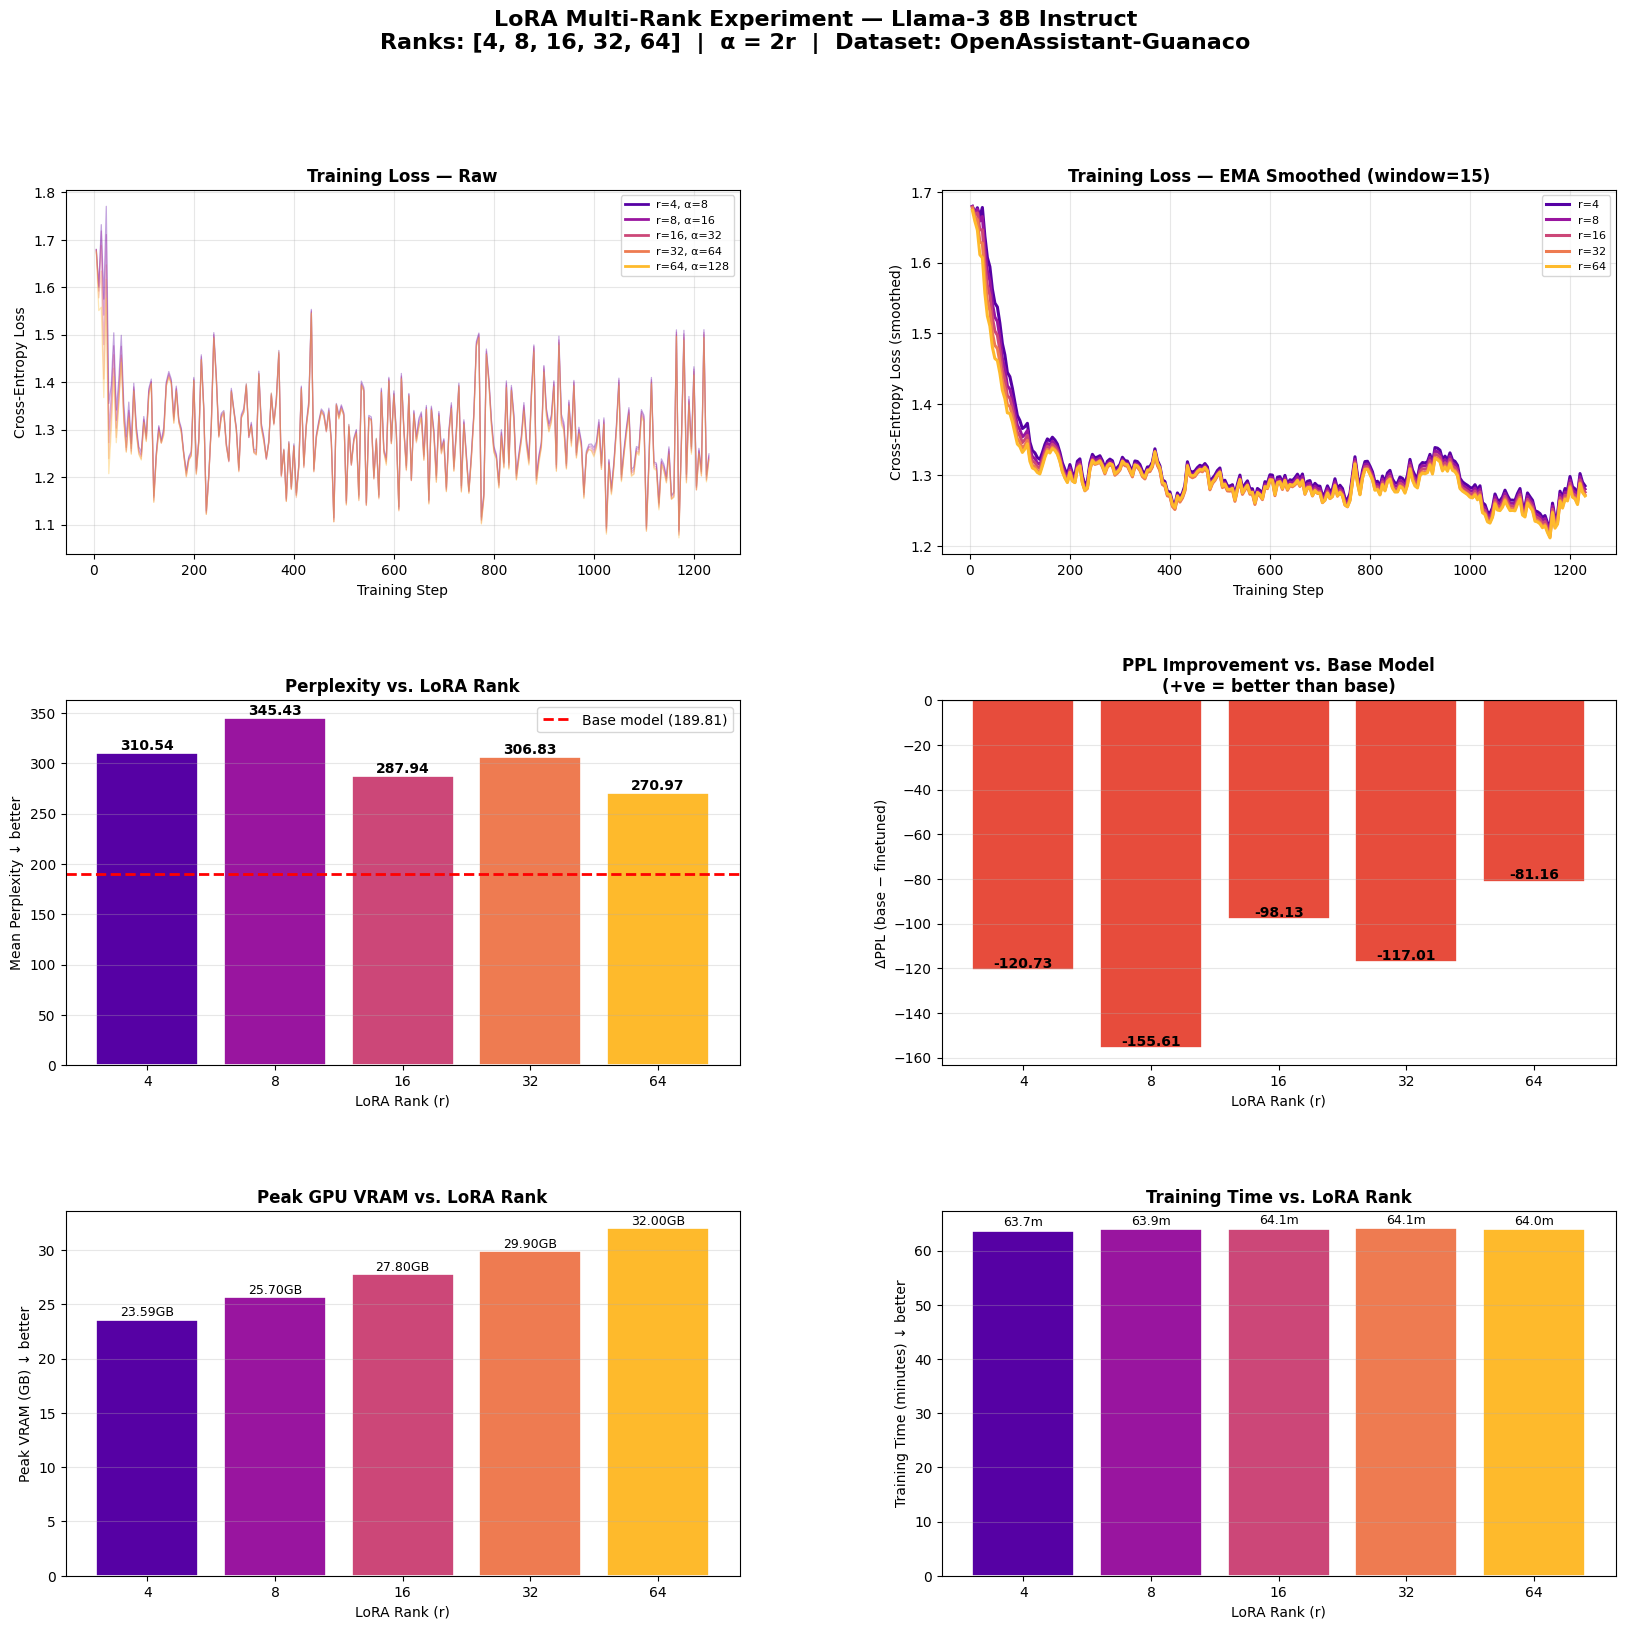


════════════════════════════════════════════════════════════════════════════════
  EXPERIMENT SUMMARY
════════════════════════════════════════════════════════════════════════════════
    Rank  Alpha  Params%   Time(m)  VRAM(GB)       PPL      ΔPPL  FinalLoss
  --------------------------------------------------------------------------
       4      8  0.2304%     63.69    23.589  310.5383 -120.7251     1.2488
       8     16  0.4597%     63.91    25.699  345.4268 -155.6136     1.2443
      16     32  0.9153%     64.09    27.800  287.9394 -98.1262     1.2405
      32     64  1.8140%     64.12    29.901  306.8253 -117.0121     1.2377
      64    128  3.5633%     64.02    32.003  270.9704 -81.1572     1.2359
  ──────────────────────────────────────────────────────────────────────────
  BASE MODEL PPL: 189.8132
  BEST FINE-TUNED: r=64 → PPL=270.9704
════════════════════════════════════════════════════════════════════════════════

  Master results saved → ./lora_rank_experiments/master_resu

In [19]:
all_results, base_ppl = run_full_experiment(config)
print(all_results)
print(base_ppl)